# Enstrophy convergence

For a single barotropic simulation, detect $t_s$ from the global enstrophy series, take the diagnostic $D(t_s, M)$ (time-mean zonal-mean of $u$ over the post-spinup window) as the long-run reference, and plot the cos-lat-weighted relative L2 error of $D(t_s, t_s+i)$ against $i$. Mark the convergence offset $i_c$ at which the error first drops below CONVERGENCE_THRESHOLD and stays below for HOLD consecutive steps; the absolute convergence index is $t_c = t_s + i_c$.

All computations come from `ml.diagnostics`: `compute_enstrophy`, `find_spinup_time`, `compute_time_mean_zonal_mean`, `zonal_mean_convergence_errors`, `find_zonal_mean_convergence_time`.

In [41]:
SIM_DIR = "../../output/barotropic_stirring-T85/simulations/111"
CONVERGENCE_THRESHOLD = 0.05
HOLD = 3
N_FRAMES = 8

SPINUP_WINDOW = 8
SPINUP_HOLD = 3
SPINUP_TOLERANCE = 0.10

In [42]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

from ml.cmd.rotating_globe import load_data
from ml.diagnostics import (
    compute_enstrophy,
    compute_time_mean_zonal_mean,
    find_spinup_time,
    find_zonal_mean_convergence_time,
    zonal_mean_convergence_errors,
)

In [43]:
ds = load_data(SIM_DIR)
vor = ds.vor.values
u = ds.ucomp.values
lat = ds.lat.values
M = vor.shape[0]
print(f"Loaded: M = {M}, grid {len(lat)} x {ds.sizes['lon']}")

Loaded: M = 105, grid 128 x 256


/var/folders/4p/1s3ml81d7sx9zjdx06ttqs8r0000gp/T/ipykernel_8377/4156146158.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


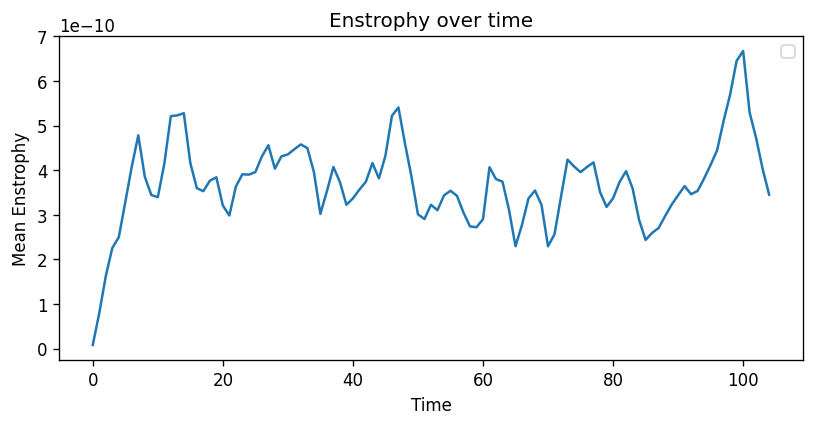

In [44]:
enstrophy = compute_enstrophy(vor, lat)
fig, ax = plt.subplots(figsize=(8, 3.5))
plt.plot(enstrophy)
ax.set_title("Enstrophy over time")
ax.set_xlabel("Time")
ax.set_ylabel("Mean Enstrophy")
ax.legend()

spinup_time = 99


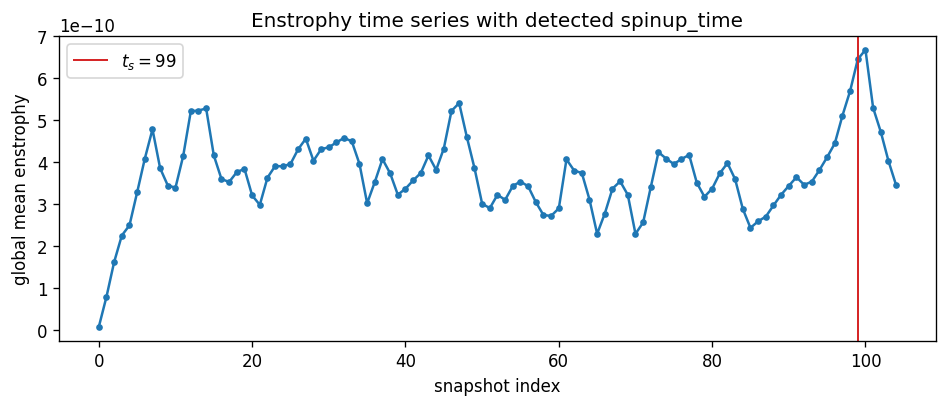

In [ ]:
spinup_time = find_spinup_time(enstrophy)
print(f"spinup_time = {spinup_time}")


fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(enstrophy, marker="o", markersize=3)
ax.axvline(spinup_time, color="C3", linestyle="-", linewidth=1.2, label=rf"$t_s = {spinup_time}$")
ax.set_xlabel("snapshot index")
ax.set_ylabel("global mean enstrophy")
ax.set_title("Enstrophy time series with detected spinup_time")
ax.legend()
plt.tight_layout()
plt.show()

In [46]:
diagnostic_reference = compute_time_mean_zonal_mean(u, spinup_time, M)
errors = zonal_mean_convergence_errors(u, lat, spinup_time)
i_values = np.arange(1, len(errors) + 1)

In [47]:
t_c = find_zonal_mean_convergence_time(u, lat, spinup_time, CONVERGENCE_THRESHOLD, HOLD)
i_c = t_c - spinup_time
print(f"t_c = {t_c} (absolute), i_c = {i_c} (offset past spinup)")

ValueError: convergence not reached (threshold=0.05, hold=3); trajectory may not be long enough

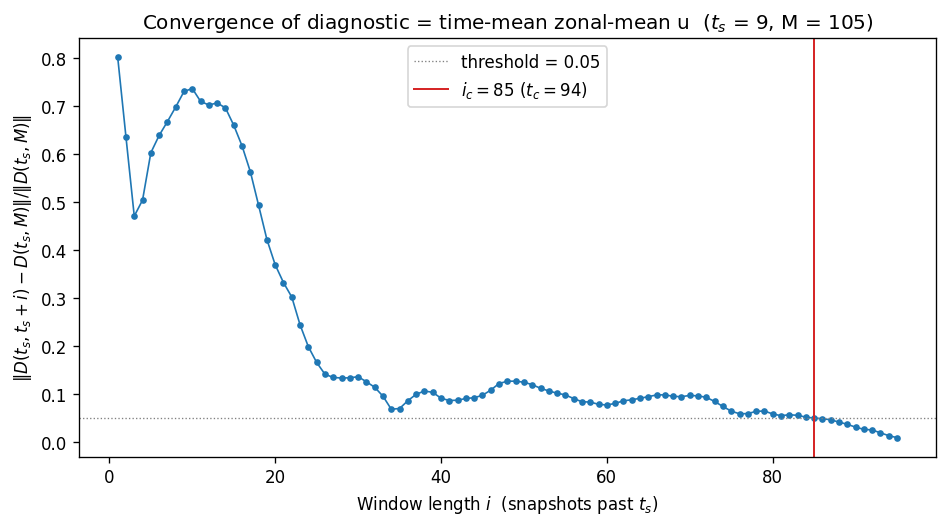

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(i_values, errors, marker="o", markersize=3, linewidth=1)
ax.axhline(CONVERGENCE_THRESHOLD, color="gray", linestyle=":", linewidth=0.8, label=f"threshold = {CONVERGENCE_THRESHOLD}")
ax.axvline(i_c, color="C3", linestyle="-", linewidth=1.2, label=rf"$i_c = {i_c}$ ($t_c = {t_c}$)")
ax.set_xlabel(r"Window length $i$  (snapshots past $t_s$)")
ax.set_ylabel(r"$\| D(t_s, t_s+i) - D(t_s, M) \| / \| D(t_s, M) \|$")
ax.set_title(f"Convergence of diagnostic = time-mean zonal-mean u  ($t_s$ = {spinup_time}, M = {M})")
ax.legend()
plt.tight_layout()
plt.show()

## Evolution of the diagnostic profile

Grid of $N$ frames at evenly-spaced window lengths $i$. Each panel shows the partial-window diagnostic $D(t_s, t_s+i)$ (blue) against the reference $D(t_s, M)$ (red). Convergence appears as the blue line settling onto the red.

In [ ]:
i_frames = np.linspace(1, M - spinup_time - 1, N_FRAMES).astype(int)
diagnostics_frames = np.stack([
    compute_time_mean_zonal_mean(u, spinup_time, spinup_time + i)
    for i in i_frames
])
print(f"i frames: {i_frames.tolist()}")

i frames: [1, 14, 27, 41, 54, 68, 81, 95]


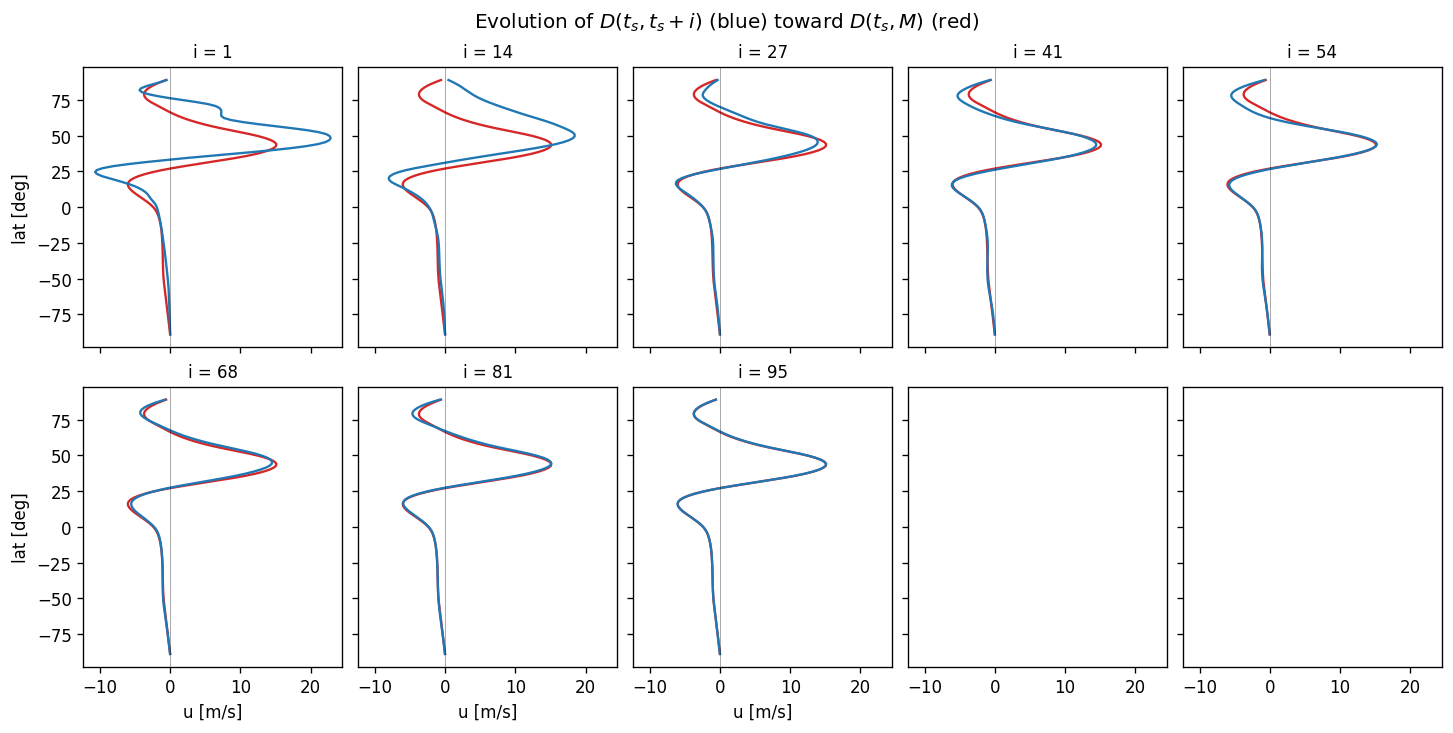

In [ ]:
ncols = 5
nrows = (N_FRAMES + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(ncols * 2.4, nrows * 3.0),
    sharex=True, sharey=True, constrained_layout=True,
)

for k, i in enumerate(i_frames):
    ax = axes.flat[k]
    ax.plot(diagnostic_reference, lat, color="C3", linewidth=1.4)
    ax.plot(diagnostics_frames[k], lat, color="C0", linewidth=1.4)
    ax.axvline(0.0, color="k", linewidth=0.4, alpha=0.5)
    ax.set_title(f"i = {i}", fontsize=10)
    if k % ncols == 0:
        ax.set_ylabel("lat [deg]")
    if k >= (nrows - 1) * ncols:
        ax.set_xlabel("u [m/s]")

fig.suptitle(r"Evolution of $D(t_s, t_s+i)$ (blue) toward $D(t_s, M)$ (red)")
plt.show()